In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import gc

In [ ]:
df_Master_FE = pd.read_parquet('df_Master_FE.parquet')
df_transaction = pd.read_parquet('df_transaction_features.parquet')
df_rfm = pd.read_parquet('df_rfm.parquet')

## Business Overview

In [ ]:
total_revenue = df_transaction['final_amount'].sum()

total_trans = (
    df_transaction['transaction_id']
    .nunique()
)

atv = total_revenue / total_trans

print(f"Total Revenue: Rp{total_revenue:,.2f}")
print(f"Total Transactions: {total_trans:,}")
print(f"Average Transaction Value: Rp{atv:,.2f}")

Total Revenue: Rp443,992,480.00
Total Transactions: 14,623,691
Average Transaction Value: Rp30.36


## Time Based analysis

In [ ]:
daily_trend = (
    df_transaction
    .groupby(df_transaction['created_at'].dt.date)
    .agg({
        'final_amount': 'sum',
        'discount_applied': 'sum',
        'transaction_id': 'count'
    })
)

daily_trend[
    ['final_amount', 'discount_applied']
].plot(figsize=(15,5))

plt.title('Daily Revenue vs Discount Trend')
plt.ylabel('Amount')

plt.show()

SyntaxError: ':' expected after dictionary key (2112213603.py, line 6)

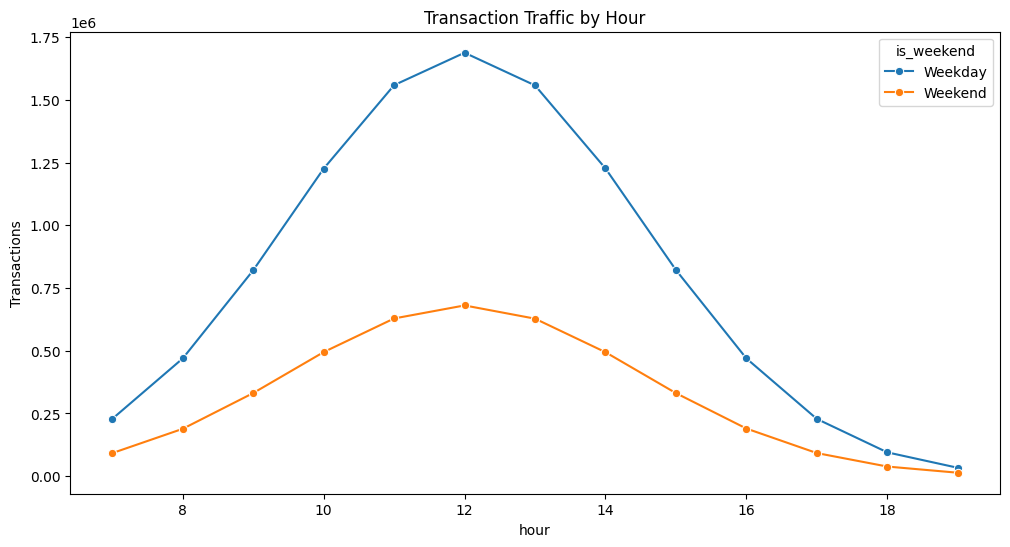

In [ ]:
hourly_dist = (
    df_Master_FE
    .groupby(['hour', 'is_weekend'])['transaction_id']
    .nunique()
    .reset_index(name='trans_count')
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly_dist,
    x='hour',
    y='trans_count',
    hue='is_weekend',
    marker='o'
)

plt.title('Transaction Traffic by Hour')
plt.ylabel('Transactions')

plt.show()

In [ ]:
hourly_revenue = (
    df_transaction
    .groupby('hour')['final_amount']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=hourly_revenue,
    x='hour',
    y='final_amount',
    marker='o'
)

plt.title('Revenue per Hour')
plt.ylabel('Revenue')

plt.show()

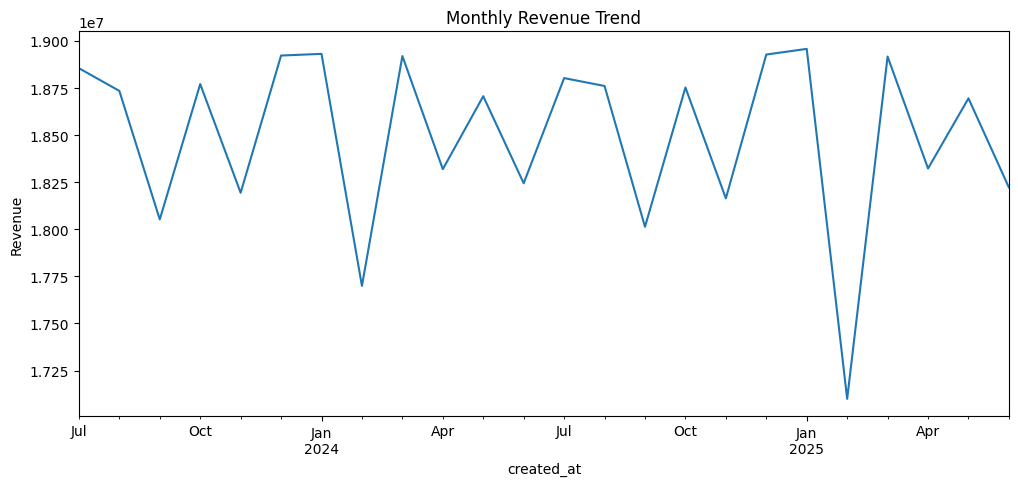

In [23]:
monthly_trend = (
    df_transaction
    .groupby(
        df_transaction['created_at'].dt.to_period('M')
    )['final_amount']
    .sum()
)

monthly_trend.plot(figsize=(12,5))

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')

plt.show()

In [ ]:
period_rev = (
    df_transaction
    .groupby('transaction_period')['final_amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=period_rev.index,
    y=period_rev.values
)

plt.title('Revenue by Transaction Period')
plt.ylabel('Revenue')

plt.show()

In [ ]:
basket_period = (
    df_transaction
    .groupby('transaction_period')['basket_size']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=basket_period.index,
    y=basket_period.values
)

plt.title('Average Basket Size by Period')
plt.ylabel('Average Basket Size')

plt.show()

In [ ]:
voucher_period = (
    df_transaction
    .groupby('transaction_period')['discount_applied']
    .mean()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=voucher_period.index,
    y=voucher_period.values
)

plt.title('Average Discount by Transaction Period')
plt.ylabel('Average Discount')

plt.show()

In [ ]:
period_weekend = (
    df_Master_FE
    .groupby(
        ['transaction_period', 'is_weekend']
    )['transaction_id']
    .nunique()
    .reset_index(name='total_trans')
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=period_weekend,
    x='transaction_period',
    y='total_trans',
    hue='is_weekend'
)

plt.title('Transaction by Period and Day Type')
plt.ylabel('Transactions')

plt.show()

## Customer Analysis

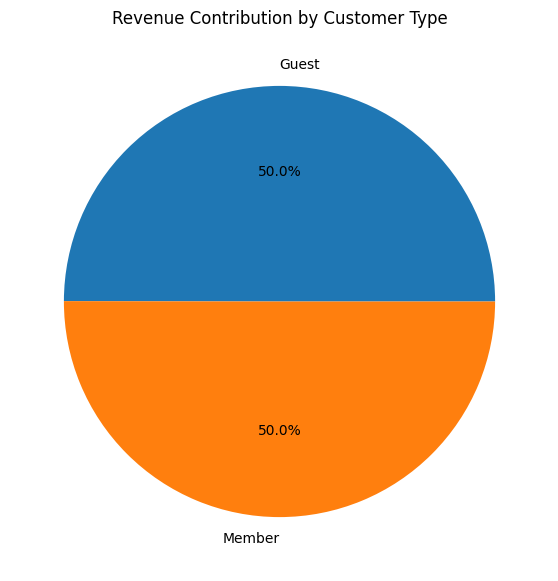

In [24]:
customer_rev = (
    df_transaction
    .groupby('member_status')['final_amount']
    .sum()
)

plt.figure(figsize=(7,7))

plt.pie(
    customer_rev,
    labels=customer_rev.index,
    autopct='%1.1f%%'
)

plt.title('Revenue Contribution by Customer Type')

plt.show()

In [ ]:
member_behavior = (
    df_transaction
    .groupby('member_status')
    .agg({
        'transaction_id': 'count',
        'final_amount': 'mean'
    })
)

print(member_behavior)

               transaction_id  final_amount
member_status                              
Guest                 7310827     30.348576
Member                7312864     30.373737


In [26]:
repeat_cust = (
    df_rfm['is_repeat_customer']
    .value_counts()
)

print(repeat_cust)

is_repeat_customer
Repeat Customer      1536904
One-Time Customer     659353
Name: count, dtype: int64


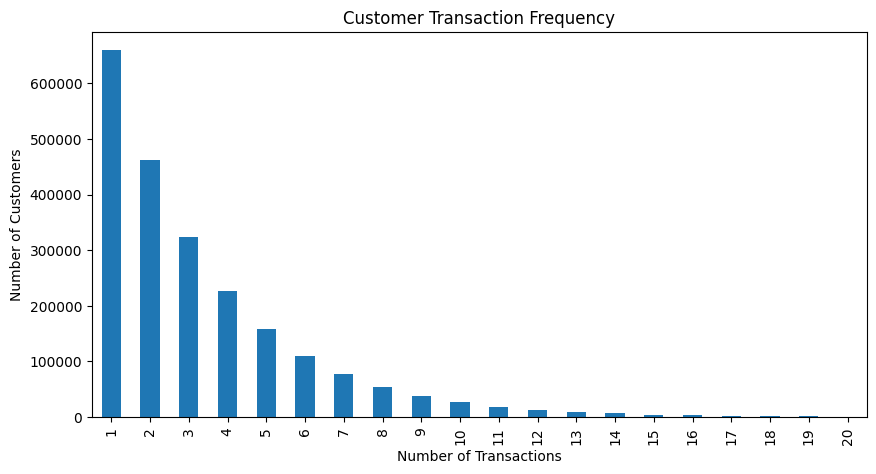

In [ ]:
repeat_dist = (
    df_rfm['Frequency']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

repeat_dist.head(20).plot(kind='bar')

plt.title('Customer Transaction Frequency')

plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')

plt.show()

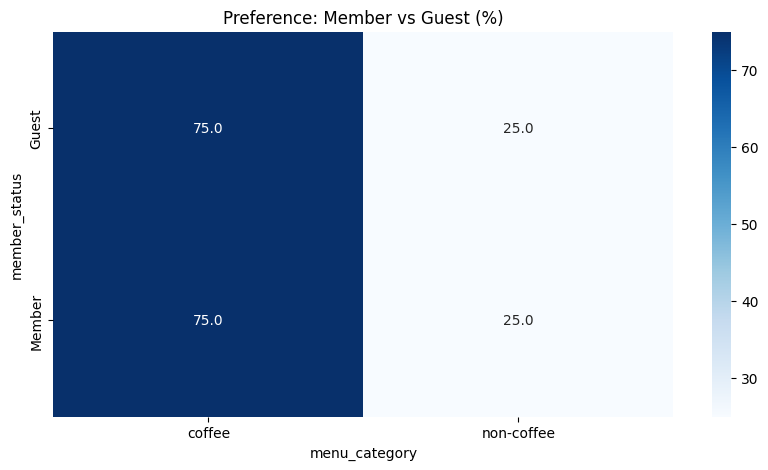

In [ ]:
member_pref = (
    df_Master_FE
    .groupby(
        ['member_status', 'menu_category']
    )['quantity']
    .sum()
    .unstack()
    .fillna(0)
)

member_pref_pct = (
    member_pref
    .div(member_pref.sum(axis=1), axis=0)
    * 100
)

plt.figure(figsize=(10,5))

sns.heatmap(
    member_pref_pct,
    annot=True,
    fmt=".1f",
    cmap='Blues'
)

plt.title('Preference: Member vs Guest (%)')

plt.show()


## Product Analysis

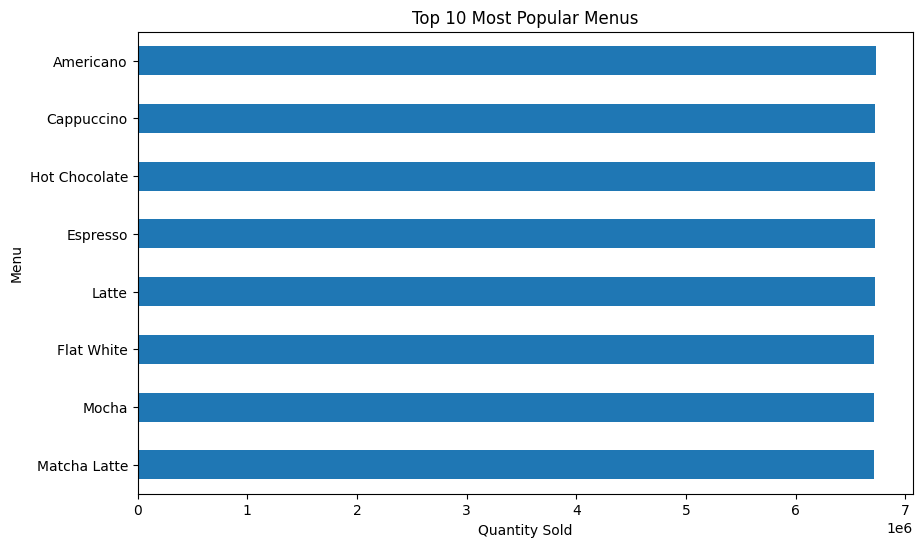

In [ ]:
top_10_menu = (
    df_Master_FE
    .groupby('item_name')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_10_menu.plot(kind='barh')

plt.gca().invert_yaxis()

plt.title('Top 10 Most Popular Menus')

plt.show()  

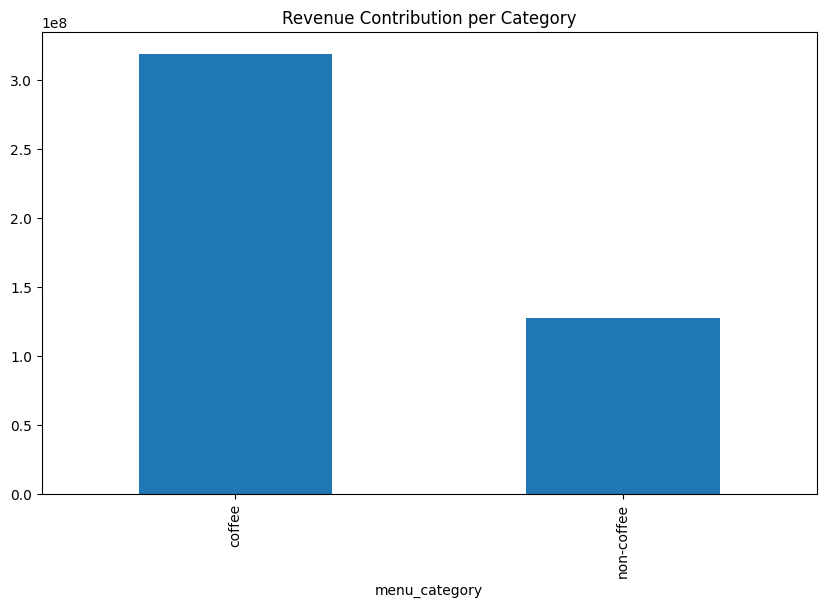

In [ ]:
category_revenue = (
    df_Master_FE
    .groupby('menu_category')['subtotal']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

category_revenue.plot(kind='bar')

plt.title('Revenue Contribution per Category')

plt.show()

In [ ]:
top_menu_category = (
    df_Master_FE
    .groupby(
        ['menu_category', 'item_name']
    )['quantity']
    .sum()
    .reset_index()
)

top_menu_category = (
    top_menu_category
    .sort_values(
        ['menu_category', 'quantity'],
        ascending=[True, False]
    )
    .groupby('menu_category')
    .head(3)
)

print(top_menu_category)


TypeError: Series.sort_values() takes 1 positional argument but 2 positional arguments (and 1 keyword-only argument) were given

In [ ]:
menu_period = (
    df_Master_FE
    .groupby(
        ['transaction_period', 'menu_category']
    )['quantity']
    .sum()
    .unstack()
    .fillna(0)
)

menu_period_pct = (
    menu_period
    .div(menu_period.sum(axis=1), axis=0)
    * 100
)

plt.figure(figsize=(12,6))

sns.heatmap(
    menu_period_pct,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

plt.title('Menu Preference by Transaction Period (%)')

plt.show()

## Spatial Analysis

In [ ]:
city_rev = (
    df_transaction
    .groupby('city')['final_amount']
    .sum()
    .sort_values(ascending=False)
)

print(city_rev.head(10))

city
Seksyen 21              44436752.0
Bandar Seri Mulia       44436536.0
Taman Damansara         44434224.0
Kampung Changkat        44418092.0
USJ 57W                 44406984.0
Alam Tun Hussein Onn    44399224.0
Kondominium Putra       44376848.0
PJS8                    44371544.0
Damansara Saujana       44367976.0
USJ 89q                 44344004.0
Name: final_amount, dtype: float32


In [ ]:
city_atv = (
    df_transaction
    .groupby('city')['final_amount']
    .mean()
    .sort_values(ascending=False)
)

print(city_atv.head(10))

city_menu_pref = (
    df_Master_FE
    .groupby(
        ['city', 'menu_category']
    )['quantity']
    .sum()
    .unstack()
    .fillna(0)
)

city_pref_pct = (
    city_menu_pref
    .div(city_menu_pref.sum(axis=1), axis=0)
    * 100
)

plt.figure(figsize=(12,8))

sns.heatmap(
    city_pref_pct,
    annot=True,
    fmt=".1f",
    cmap='YlOrRd'
)

plt.title('Menu Preference by City (%)')

plt.show()


city
USJ 57W                 30.374550
Kondominium Putra       30.371117
PJS8                    30.370729
Taman Damansara         30.369791
Bandar Seri Mulia       30.369276
Kampung Changkat        30.363310
Damansara Saujana       30.357046
USJ 89q                 30.356512
Alam Tun Hussein Onn    30.341141
Seksyen 21              30.338156
Name: final_amount, dtype: float32


## Payment Analysis

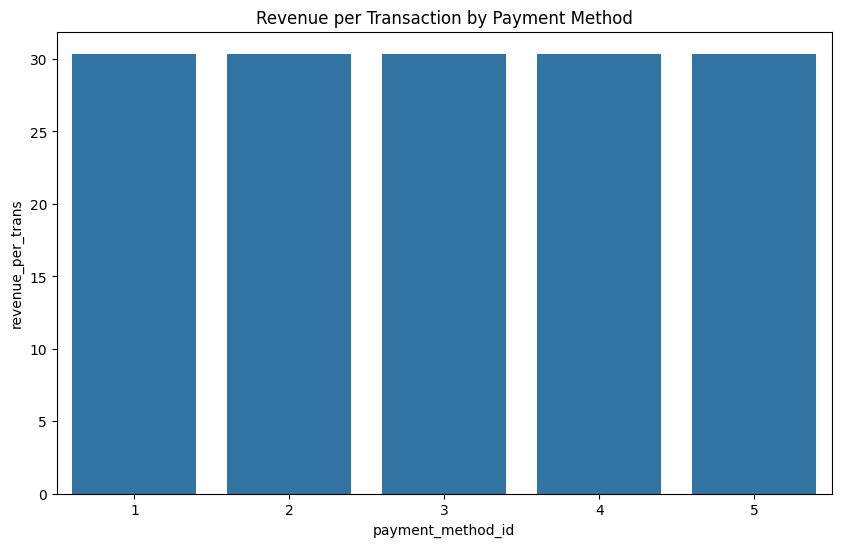

In [ ]:
payment_stats = (
    df_transaction
    .groupby('method_name')
    .agg({
        'transaction_id': 'count',
        'final_amount': 'sum'
    })
    .rename(columns={
        'transaction_id': 'total_trans'
    })
)

total_qty_payment = (
    df_Master_FE
    .groupby('method_name')['quantity']
    .sum()
)

payment_behavior = payment_stats.copy()

payment_behavior['total_quantity'] = total_qty_payment

payment_behavior['avg_items_per_trans'] = (
    payment_behavior['total_quantity']
    / payment_behavior['total_trans']
)

payment_behavior['revenue_per_trans'] = (
    payment_behavior['final_amount']
    / payment_behavior['total_trans']
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=payment_behavior.index,
    y=payment_behavior['revenue_per_trans']
)

plt.title('Revenue per Transaction by Payment Method')

plt.show()

## Promotion Analysis

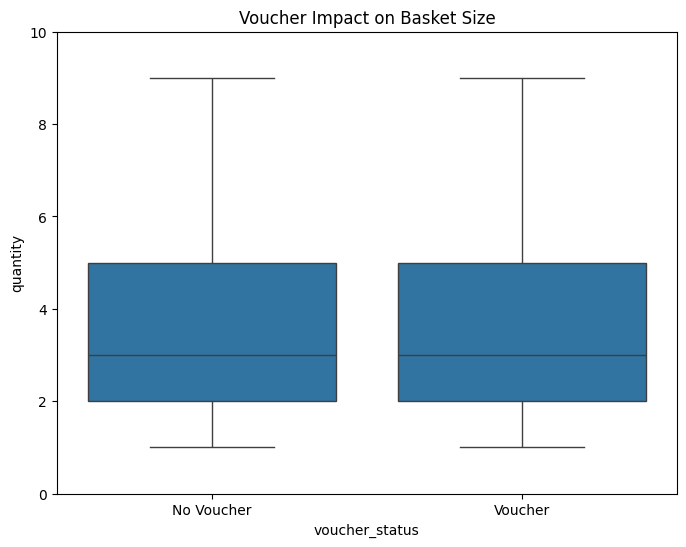

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_transaction,
    x='is_voucher_used',
    y='basket_size'
)

plt.title('Voucher Impact on Basket Size')

plt.ylim(0,10)

plt.show()

# Voucher Sensitivity
voucher_sensitivity = (
    df_transaction
    .groupby('member_status')
    .agg({
        'discount_applied': 'mean',
        'final_amount': 'mean'
    })
)

voucher_sensitivity['discount_ratio (%)'] = (
    voucher_sensitivity['discount_applied']
    /
    (
        voucher_sensitivity['final_amount']
        +
        voucher_sensitivity['discount_applied']
    )
    * 100
).round(2)

print(voucher_sensitivity)

## Others Analytics

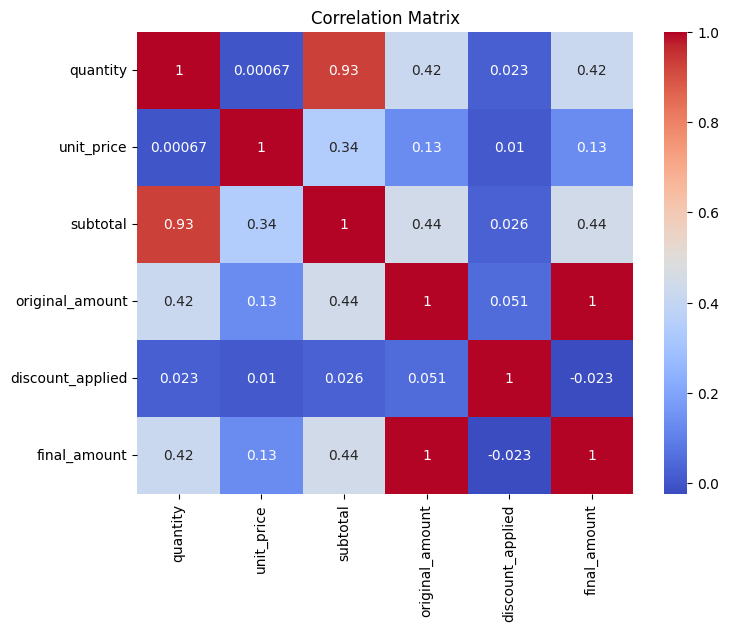

In [ ]:
df_sample = (
    df_Master_FE
    .sample(frac=0.01, random_state=42)
)

corr_cols = [
    'quantity',
    'unit_price',
    'subtotal',
    'original_amount',
    'discount_applied',
    'final_amount'
]

corr_matrix = (
    df_sample[corr_cols]
    .corr()
)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_transaction['basket_size'],
    bins=20
)

plt.title('Basket Size Distribution')

plt.xlabel('Basket Size')
plt.ylabel('Frequency')

plt.show()

In [ ]:
df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], 4, labels=[4, 3, 2, 1])
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'], 4, labels=[1, 2, 3, 4])
def segment_customer(df):
    if df['F_Score'] == 4 and df['M_Score'] == 4:
        return 'Champions'
    elif df['R_Score'] == 1:
        return 'At Risk'
    elif df['F_Score'] >= 3:
        return 'Loyal'
    else:
        return 'Regular'

df_rfm['Segment'] = df_rfm.apply(segment_customer, axis=1)
print(df_rfm['Segment'].value_counts())

Segment
Regular      821231
Loyal        480669
Champions    465005
At Risk      429352
Name: count, dtype: int64


In [10]:
gc.collect()

0